# Common Libraries

In [1]:
import os, sys, shutil
import numpy as np
from copy import deepcopy
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"

# Mujoco
import mujoco

# Custom Libraries

In [2]:
def render_models(models, renderes, site_group_idx = [], site_size = 0.015, site_color_rgba = [1.0, 0.0, 0.0, 1.0]):
    # Scene option
    scene_option = mujoco.MjvOption()

    for site_group_i, _ in enumerate(scene_option.sitegroup):
        if site_group_i in site_group_idx:
            scene_option.sitegroup[site_group_i] = 1
        else:
            scene_option.sitegroup[site_group_i] = 0

    # Change site setting
    for model, renderer in zip(models, renderers):
        for i in range(model.nsite):
            if model.site_group[i] in site_group_idx:
                model.site_rgba[i][:] = site_color_rgba
                model.site_size[i][:] = np.repeat(site_size, 3)
    
    # Render
    for model, renderer in zip(models, renderers):
        data = mujoco.MjData(model)
        mujoco.mj_forward(model, data)
        renderer.update_scene(data, camera=camera, scene_option=scene_option)
    
    # Make image
    fig, axes = plt.subplots(1, len(renderers))
    fig.set_figwidth(15)
    axes = axes.flatten()

    for i, renderer in enumerate(renderers):
        axes[i].imshow(renderer.render())
        axes[i].axis("off")
    axes[0].set_title(f"Original")
    axes[1].set_title(f"scaled: {scale}")
    
def get_site_group_number(model, site_name):
    site_i = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, site_name)
    group_number = model.site_group[site_i]
    return group_number

In [3]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from mujoco_util import get_body_pos, get_site_pos, get_geom_pos
from sj_datastructure import make_3d_dataset
from vis_3D import Plotter3D

# Params

In [15]:
model_path = "/mnt/sdb2/DeepProprioception/MyoSuite/muscle_mimic/muscle_mimic_scaled.xml"
# model_path = "/home/seojin/Tools/biomechanics/musclemimic_models/musclemimic_models/model/body/myofullbody.xml"
# model_path = "/home/seojin/Tools/biomechanics/musclemimic_models2/musclemimic_models/model/arm/myoarm_bimanual.xml"

scale = 3
save_path = "/mnt/ext1/seojin/temp/scale/scaled_param.npz"
is_plot = True

target_site_suffix = "Mimic_Site" # "marker"
excludes = ["world", "Bimanual", "root"] # ["world"] 

# Initialize model

In [16]:
# Mujoco model
origin_model = mujoco.MjModel.from_xml_path(model_path)
scaled_model = deepcopy(origin_model)

## Joint
joint_names = [mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_JOINT, i) for i in range(origin_model.njnt)]

## Site
site_names = [mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_SITE, i) for i in range(origin_model.nsite)]

# Marker
one_marker_name = [site_name for site_name in site_names if site_name.endswith(target_site_suffix)][0]
marker_group_number = get_site_group_number(origin_model, one_marker_name)
marker_site_names = [
    mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_SITE, i)
    for i in range(origin_model.nsite)
    if origin_model.site_group[i] == marker_group_number
    and mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_SITE, i) is not None
]

## Body
body_names = np.array([origin_model.body(i).name for i in range(len(origin_model.body_pos))])
target_body_names = body_names[np.isin(body_names, excludes) == False]
target_body_ids = [mujoco.mj_name2id(origin_model, mujoco.mjtObj.mjOBJ_BODY, body_name) for body_name in target_body_names]

## Tendon
muscle_actuated = origin_model.actuator_trntype == mujoco.mjtTrn.mjTRN_TENDON
tendon_ids = origin_model.actuator_trnid[muscle_actuated, 0]
tendon_names = [mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_TENDON, int(t_id)) for t_id in tendon_ids]

# Constants

In [17]:
n_bodies = origin_model.nbody
n_sites = origin_model.nsite
n_geoms = origin_model.ngeom
n_vertices = origin_model.nmeshvert

scales = np.ones((n_bodies, 1)) 
scales[target_body_ids] = scales[target_body_ids, :] * scale

# Visualization

In [18]:
# Camera
camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_FREE
camera.lookat[:] = [0, 0, 0]
camera.distance = 4.0
camera.azimuth = 270
camera.elevation = 0

models = [origin_model, scaled_model]
for model in models:
    # Remove ground
    for geom_id in range(model.ngeom):
        if model.geom_type[geom_id] == mujoco.mjtGeom.mjGEOM_PLANE:
            model.geom_rgba[geom_id, 3] = 0.0
            
origin_render = mujoco.Renderer(origin_model, height=400, width=600)
scaled_renderer = mujoco.Renderer(scaled_model, height=400, width=600)
renderers = [origin_render, scaled_renderer]

plotting = Plotter3D()

# Body

A **Body** is a reference frame defining a rigid body, serving as a node that includes its physical properties and child elements. The **body mixer** defines how much child should be scaled when the parent is scaled.

body_parentid stores the ID of the current body’s parent

In [19]:
body_mixer = np.zeros((n_bodies, n_bodies))
idx0 = np.arange(n_bodies)
idx1 = origin_model.body_parentid

body_mixer[idx0, idx1] = 1
body_scale = body_mixer @ scales

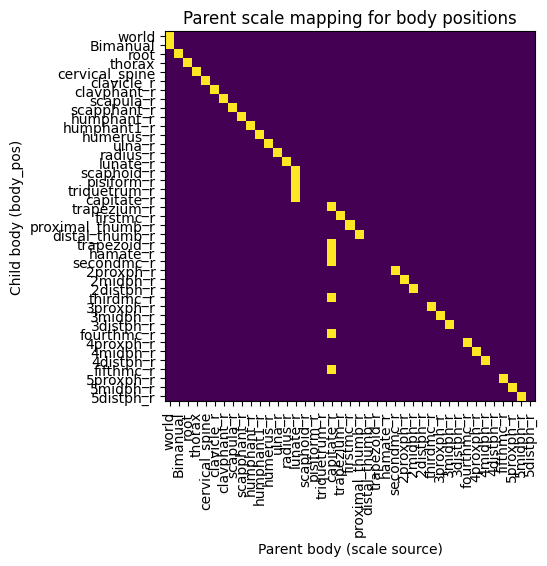

In [20]:
if is_plot:
    fig, axis = plt.subplots(1)
    axis.imshow(body_mixer)
    axis.set_xticks(np.arange(len(body_names)), body_names, rotation = 90)
    axis.set_yticks(np.arange(len(body_names)), body_names)
    
    axis.set_xlabel("Parent body (scale source)")
    axis.set_ylabel("Child body (body_pos)")
    axis.set_title("Parent scale mapping for body positions")

In [21]:
scaled_model.body_pos[:] = origin_model.body_pos * body_scale

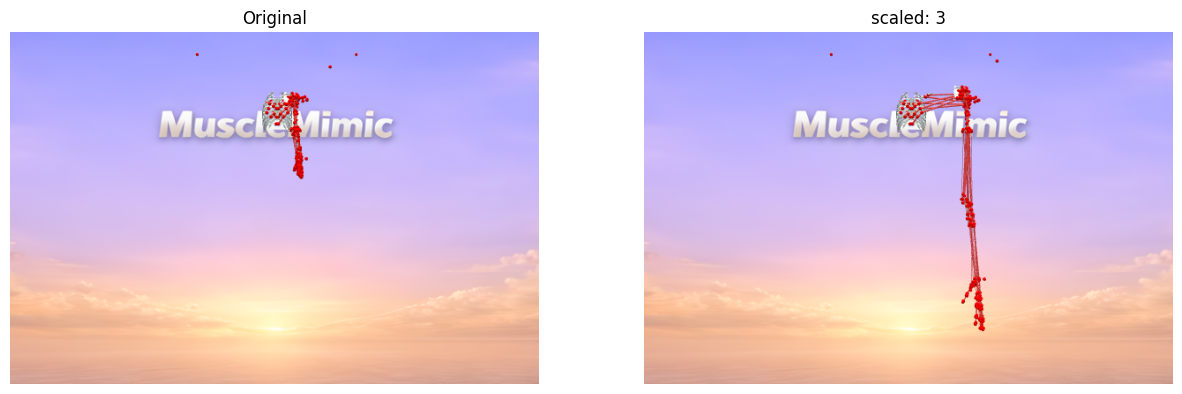

In [22]:
render_models(models, renderers, site_group_idx = np.arange(6), site_size = 0.015)

In [23]:
origin_body_pos = get_body_pos(origin_model, mujoco.MjData(origin_model))
scaled_body_pos = get_body_pos(scaled_model, mujoco.MjData(scaled_model))

origin_body_ds = make_3d_dataset(origin_body_pos[["global_x", "global_y", "global_z"]].to_numpy()[None, :, :],
                                 "3D",
                                 element_dataset_names = ["Time", "Label", "Coord"],
                                 dataset1_dim_names = [0],
                                 dataset2_dim_names = origin_body_pos["body_name"].values,
                                 dataset3_dim_names = ["X", "Y", "Z"])

scaled_body_ds = make_3d_dataset(scaled_body_pos[["global_x", "global_y", "global_z"]].to_numpy()[None, :, :],
                                 "3D",
                                 element_dataset_names = ["Time", "Label", "Coord"],
                                 dataset1_dim_names = [0],
                                 dataset2_dim_names = scaled_body_pos["body_name"].values,
                                 dataset3_dim_names = ["X", "Y", "Z"])

plotting.plot_multiple_datasets([origin_body_ds, scaled_body_ds])

# Site

In [24]:
site_mixer = np.zeros((n_sites, n_bodies))
idx0 = np.arange(n_sites)
idx1 = origin_model.site_bodyid
site_mixer[idx0, idx1] = 1.0
site_scale = site_mixer @ scales
scaled_model.site_pos[:] = origin_model.site_pos * site_scale

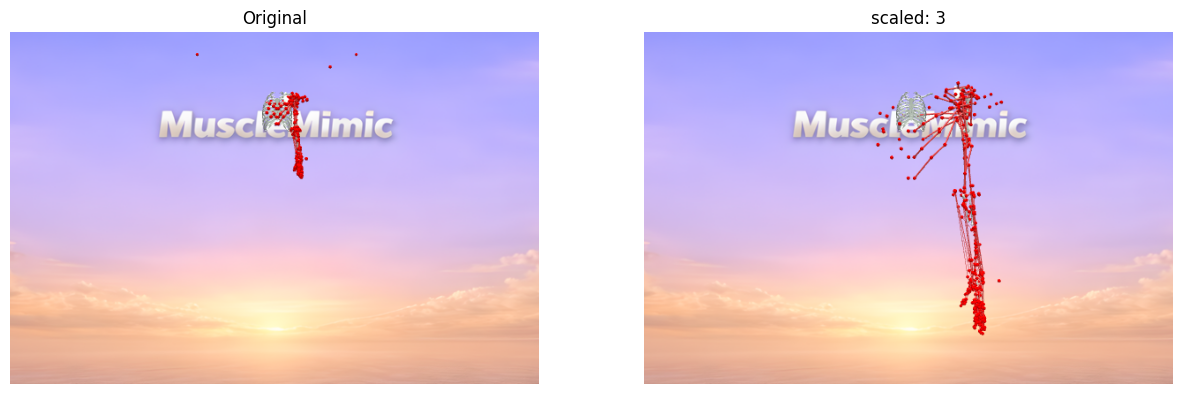

In [25]:
render_models(models, renderers, site_group_idx = np.arange(6), site_size = 0.015)

In [26]:
origin_site_pos = get_site_pos(origin_model, mujoco.MjData(origin_model))
scaled_site_pos = get_site_pos(scaled_model, mujoco.MjData(scaled_model))

origin_site_ds = make_3d_dataset(origin_site_pos[["global_x", "global_y", "global_z"]].to_numpy()[None, :, :],
                                 "3D",
                                 element_dataset_names = ["Time", "Label", "Coord"],
                                 dataset1_dim_names = [0],
                                 dataset2_dim_names = origin_site_pos["site_name"].values,
                                 dataset3_dim_names = ["X", "Y", "Z"])

scaled_site_ds = make_3d_dataset(scaled_site_pos[["global_x", "global_y", "global_z"]].to_numpy()[None, :, :],
                                 "3D",
                                 element_dataset_names = ["Time", "Label", "Coord"],
                                 dataset1_dim_names = [0],
                                 dataset2_dim_names = scaled_site_pos["site_name"].values,
                                 dataset3_dim_names = ["X", "Y", "Z"])

plotting.plot_multiple_datasets([origin_site_ds, scaled_site_ds])

# Geometry

In [27]:
geom_mixer = np.zeros((n_geoms, n_bodies))
idx0 = np.arange(n_geoms)
idx1 = origin_model.geom_bodyid
geom_mixer[idx0, idx1] = 1.0
geom_scale = geom_mixer @ scales
scaled_model.geom_pos[:] = origin_model.geom_pos * geom_scale
scaled_model.geom_size[:] = origin_model.geom_size * geom_scale

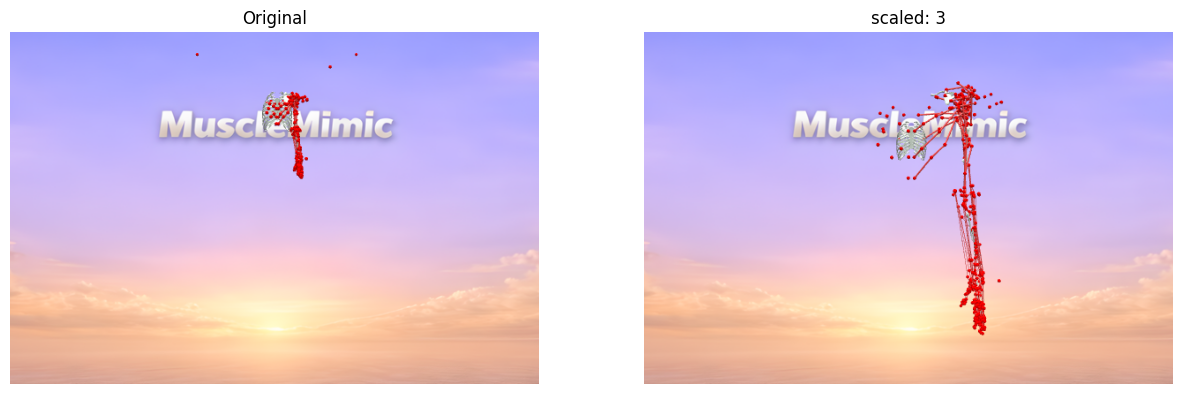

In [28]:
render_models(models, renderers, site_group_idx = np.arange(6))

In [29]:
origin_geom_pos = get_geom_pos(model_path, origin_model, mujoco.MjData(origin_model))
scaled_geom_pos = get_geom_pos(model_path, scaled_model, mujoco.MjData(scaled_model))

def clean_geom_pos(df):
    df_clean = df.dropna(subset=["geom_name"]).copy()
    df_clean = df_clean[df_clean["geom_name"].astype(str).str.strip() != ""]
    return df_clean

origin_geom_pos = clean_geom_pos(origin_geom_pos)
scaled_geom_pos = clean_geom_pos(scaled_geom_pos)

origin_geom_ds = make_3d_dataset(origin_geom_pos[["global_x", "global_y", "global_z"]].to_numpy()[None, :, :],
                                 "3D",
                                 element_dataset_names = ["Time", "Label", "Coord"],
                                 dataset1_dim_names = [0],
                                 dataset2_dim_names = origin_geom_pos["geom_name"].values,
                                 dataset3_dim_names = ["X", "Y", "Z"])

scaled_geom_ds = make_3d_dataset(scaled_geom_pos[["global_x", "global_y", "global_z"]].to_numpy()[None, :, :],
                                 "3D",
                                 element_dataset_names = ["Time", "Label", "Coord"],
                                 dataset1_dim_names = [0],
                                 dataset2_dim_names = scaled_geom_pos["geom_name"].values,
                                 dataset3_dim_names = ["X", "Y", "Z"])

plotting.plot_multiple_datasets([origin_geom_ds, scaled_geom_ds])

# Vertex

In [30]:
vertex_mixer = np.zeros((n_vertices, n_bodies))
for i in np.arange(n_bodies):
    for g in np.arange(origin_model.body_geomadr[i], origin_model.body_geomadr[i] + origin_model.body_geomnum[i]):
        mesh_id = origin_model.geom_dataid[g]
        if mesh_id != -1:
            vertex_mixer[origin_model.mesh_vertadr[mesh_id] : origin_model.mesh_vertadr[mesh_id] + origin_model.mesh_vertnum[mesh_id], i] = 1
vertex_scale = vertex_mixer @ scales
scaled_model.mesh_vert[:] = origin_model.mesh_vert * vertex_scale

In [31]:
for mesh_id in range(scaled_model.nmesh):
    mujoco.mjr_uploadMesh(scaled_model, scaled_renderer._mjr_context, mesh_id)

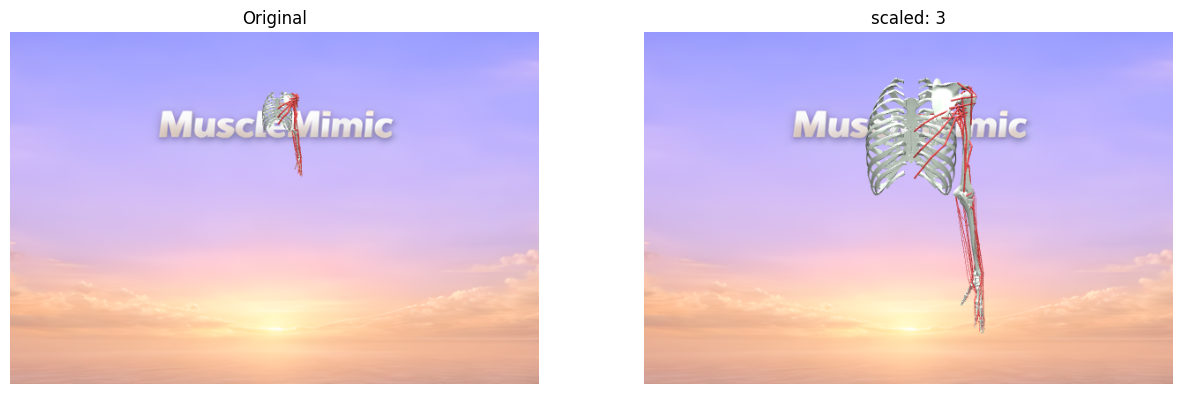

In [32]:
render_models(models, renderers, site_group_idx = [4], site_size = 0.0)

# Tendon

In [33]:
origin_tendon_length = deepcopy(origin_model.tendon_length0)

In [34]:
muscle_actuated = scaled_model.actuator_trntype == mujoco.mjtTrn.mjTRN_TENDON
data = mujoco.MjData(scaled_model)
data.qpos = scaled_model.qpos0
mujoco.mj_forward(scaled_model, data)
scaled_model.tendon_length0[tendon_ids] = data.ten_length[tendon_ids]

In [35]:
scaled_tendon_length = deepcopy(scaled_model.tendon_length0)

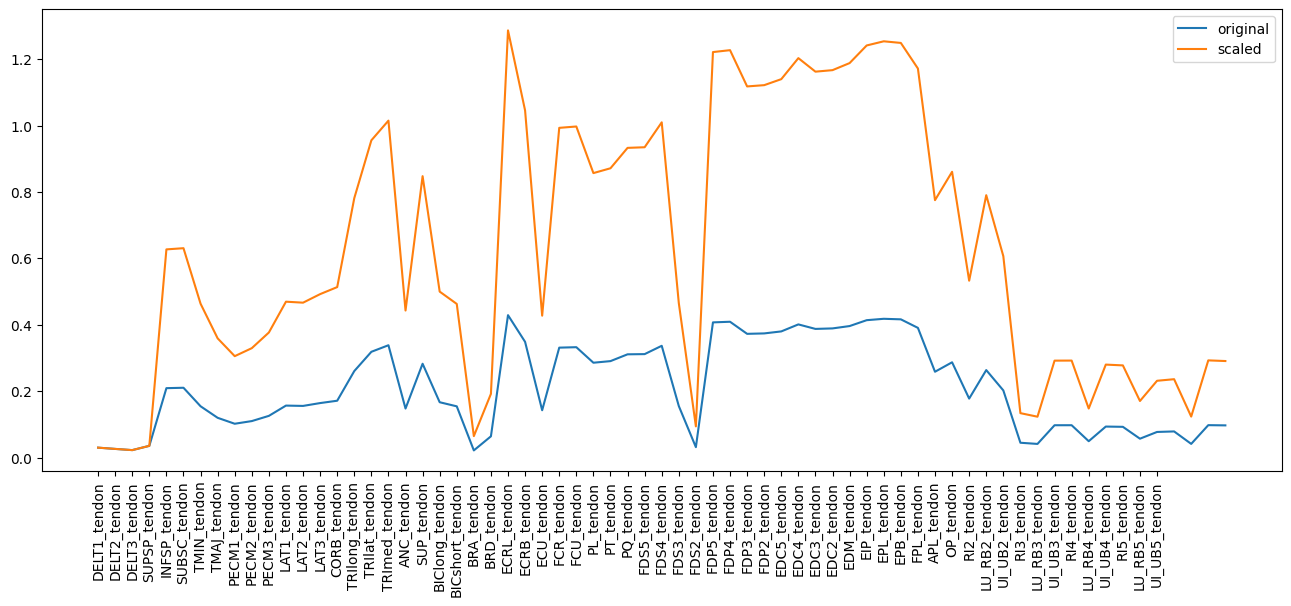

In [36]:
if is_plot:
    fig, axis = plt.subplots(1)
    fig.set_figwidth(16)
    fig.set_figheight(6)
    plt.plot(origin_tendon_length, label = "original")
    plt.plot(scaled_tendon_length, label = "scaled")
    plt.xticks(np.arange(len(tendon_names)), tendon_names, rotation = 90)
    plt.legend()

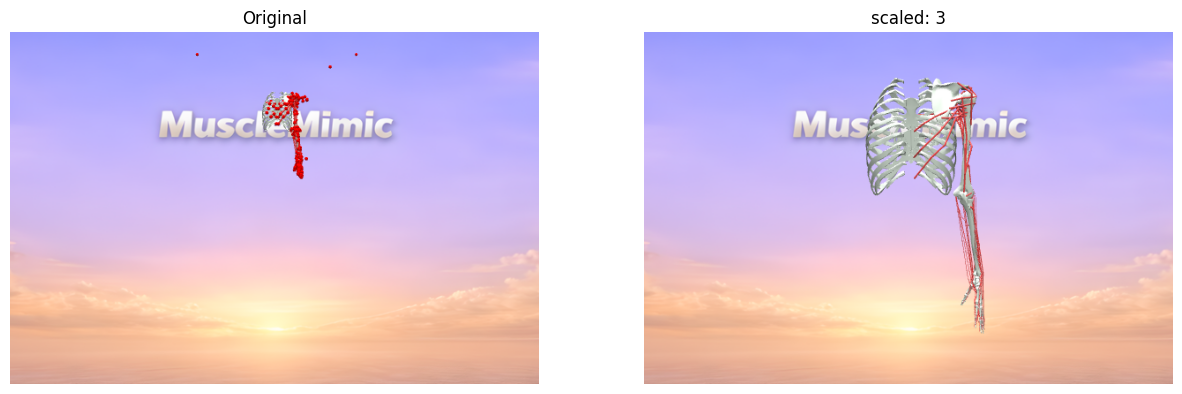

In [37]:
render_models(models, renderers, site_group_idx = np.arange(6))

# Save result

In [38]:
params_to_save = {
    "body_pos": scaled_model.body_pos,
    "site_pos": scaled_model.site_pos,
    "geom_pos": scaled_model.geom_pos,
    "geom_size": scaled_model.geom_size,
    "tendon_length0" : scaled_model.tendon_length0,
}

np.savez(save_path, **params_to_save)
print(f"save: {save_path}")

save: /mnt/ext1/seojin/temp/scale/scaled_param.npz
